In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
import sqlite3

In [81]:
con = sqlite3.connect(r'data/password_data.sqlite')

In [82]:
data = pd.read_sql_query("SELECT * FROM Users", con)

In [83]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   index     100000 non-null  int64
 1   password  100000 non-null  str  
 2   strength  100000 non-null  int64
dtypes: int64(2), str(1)
memory usage: 2.3 MB


In [84]:
data.shape

(100000, 3)

In [85]:
data.head()

,index,password,strength
0,0,zxe870819,1
1,1,xw46454nr23l,1
2,2,soporte13,1
3,3,accounts6000webhost.com,2
4,4,c443balg,1


In [86]:
data.columns

Index(['index', 'password', 'strength'], dtype='str')

In [87]:
data.drop(["index"], axis=1, inplace=True)

In [88]:
data.head()

,password,strength
0,zxe870819,1
1,xw46454nr23l,1
2,soporte13,1
3,accounts6000webhost.com,2
4,c443balg,1


In [89]:
data.duplicated().sum()

np.int64(0)

In [90]:
data.isnull().any().sum()

np.int64(0)

In [91]:
data.dtypes

password      str
strength    int64
dtype: object

In [92]:
data["strength"]

0        1
1        1
2        1
3        2
4        1
        ..
99995    1
99996    1
99997    1
99998    1
99999    1
Name: strength, Length: 100000, dtype: int64

In [93]:
data["strength"].unique()

array([1, 2, 0])

In [94]:
data.columns

Index(['password', 'strength'], dtype='str')

In [95]:
data['password'][0]

'zxe870819'

In [96]:
type(data['password'][0])

str

In [97]:
data[data['password'].str.isnumeric()]

,password,strength
12280,943801,0
14992,12345,0
20958,147856,0
21671,140290,0
23269,123987,0
28569,1233214,0
31329,0159456,0
32574,363761,0
37855,4524344,0
43648,5521597,0


In [98]:
data[data['password'].str.isnumeric()].shape

(26, 2)

In [99]:
data[data['password'].str.isupper()]

,password,strength
115,EYT63119,1
273,INSPIRON6,1
338,1A2S3D4F,1
367,13269123A,1
373,YAMAZAKI82,1
...,...,...
99590,V13000993J,1
99692,65925013ABC,1
99784,01EDD055,1
99893,1UPONYOU,1


In [100]:
data[data['password'].str.isalpha()]

,password,strength
267,PomarancaÇ,1
1380,smgodt,0
3198,cuado,0
4560,jelsz,0
6380,demsxp,0
7803,secret,0
9218,caballo,0
11555,mhe,0
11667,kreedo,0
13645,nõmlich,0


In [101]:
data[data['password'].str.isalpha()].shape

(50, 2)

In [102]:
data[data['password'].str.isalnum()]

,password,strength
0,zxe870819,1
1,xw46454nr23l,1
2,soporte13,1
4,c443balg,1
5,16623670p,1
...,...,...
99995,obejofi215,1
99996,fmiopvxb64,1
99997,czvrbun38,1
99998,mymyxe430,1


In [103]:
data[data['password'].str.istitle()]

,password,strength
64,Hisanthoshjasika0,2
242,Therockrockbottom72,2
338,1A2S3D4F,1
367,13269123A,1
526,Csicskarozsika1,2
...,...,...
99168,1053815198M,1
99192,Alfranx05122023,2
99375,Kensington1956,2
99590,V13000993J,1


In [104]:
import string

In [105]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [106]:
def find_semantics(row):
    for char in row:
        if char in string.punctuation:
            return 1
        else:
            pass   

In [107]:
data["password"].apply(find_semantics)==1

0        False
1        False
2        False
3         True
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Name: password, Length: 100000, dtype: bool

In [108]:
data['password'][0]

'zxe870819'

In [109]:
len(data["password"][0])

9

In [110]:
data["length"] = data["password"].str.len()

In [111]:
def freq_lowercase(row):
    return len([char for char in row if char.islower()])/len(row)

In [112]:
def freq_uppercase(row):
    return len([char for char in row if char.isupper()])/len(row)

In [113]:
def freq_numerical_case(row):
    return len([char for char in row if char.isdigit()])/len(row)

In [114]:
data['lowercase_freq'] = np.round(data["password"].apply(freq_lowercase), 3)
data['uppercase_freq'] = np.round(data["password"].apply(freq_uppercase), 3)
data['numerical_freq'] = np.round(data["password"].apply(freq_numerical_case), 3)

In [115]:
data.head(3)

,password,strength,length,lowercase_freq,uppercase_freq,numerical_freq
0,zxe870819,1,9,0.333,0.0,0.667
1,xw46454nr23l,1,12,0.417,0.0,0.583
2,soporte13,1,9,0.778,0.0,0.222


In [119]:
def freq_special_case(row):
    special_char = []
    for char in row:
        if not char.isalpha() and not char.isdigit():
            special_char.append(char)
    return len(special_char)

In [120]:
data["special_char_freq"] = np.round(data['password'].apply(freq_special_case), 3)

In [121]:
data.head(5)

,password,strength,length,lowercase_freq,uppercase_freq,numerical_freq,special_char_freq
0,zxe870819,1,9,0.333,0.0,0.667,0
1,xw46454nr23l,1,12,0.417,0.0,0.583,0
2,soporte13,1,9,0.778,0.0,0.222,0
3,accounts6000webhost.com,2,23,0.783,0.0,0.174,1
4,c443balg,1,8,0.625,0.0,0.375,0


In [122]:
data['special_char_freq'] = data['special_char_freq']/data['length']

In [123]:
data.head()

,password,strength,length,lowercase_freq,uppercase_freq,numerical_freq,special_char_freq
0,zxe870819,1,9,0.333,0.0,0.667,0.000000
1,xw46454nr23l,1,12,0.417,0.0,0.583,0.000000
2,soporte13,1,9,0.778,0.0,0.222,0.000000
3,accounts6000webhost.com,2,23,0.783,0.0,0.174,0.043478
4,c443balg,1,8,0.625,0.0,0.375,0.000000


In [124]:
data[['length', 'strength']].groupby(['strength']).agg(["min", "max", "mean", "median"])

length                       
            min  max       mean median
strength                              
0             1    7   6.550947    7.0
1             8   13   9.611074    9.0
2            14  220  15.953421   16.0

In [125]:
data.columns

Index(['password', 'strength', 'length', 'lowercase_freq', 'uppercase_freq',
       'numerical_freq', 'special_char_freq'],
      dtype='str')

In [127]:
cols =['length', 'lowercase_freq', 'uppercase_freq', 'numerical_freq', 'special_char_freq']

for col in cols:
    print(col)
    print(data[[col, 'strength']].groupby(['strength']).agg(["min", "max", "mean", "median"]))
    print('\n')

length
         length                       
            min  max       mean median
strength                              
0             1    7   6.550947    7.0
1             8   13   9.611074    9.0
2            14  220  15.953421   16.0


lowercase_freq
         lowercase_freq                        
                    min    max      mean median
strength                                       
0                   0.0  1.000  0.708050  0.714
1                   0.0  0.923  0.630067  0.667
2                   0.0  0.917  0.424679  0.400


uppercase_freq
         uppercase_freq                        
                    min    max      mean median
strength                                       
0                   0.0  1.000  0.012872  0.000
1                   0.0  0.923  0.007915  0.000
2                   0.0  0.889  0.367633  0.429


numerical_freq
         numerical_freq                        
                    min    max      mean median
strength                            

<Axes: xlabel='strength', ylabel='special_char_freq'>

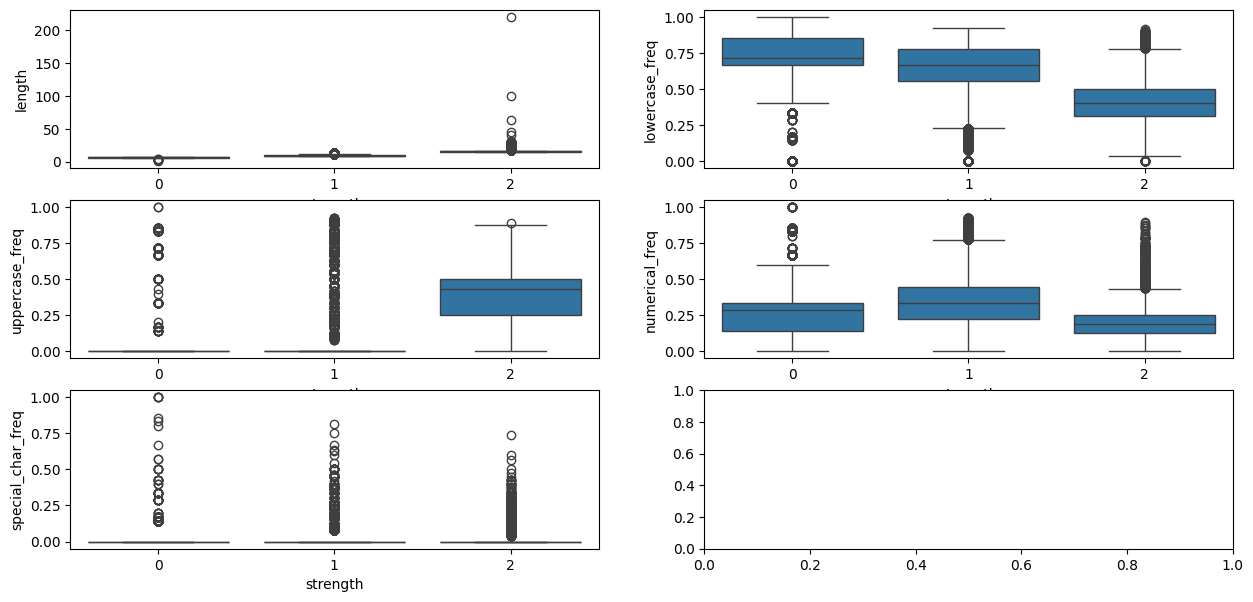

In [130]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3,2, figsize=(15,7))
sns.boxplot(x='strength', y='length', data=data, ax=ax1)
sns.boxplot(x='strength', y='lowercase_freq', data=data, ax=ax2)
sns.boxplot(x='strength', y='uppercase_freq', data=data, ax=ax3)
sns.boxplot(x='strength', y='numerical_freq', data=data, ax=ax4)
sns.boxplot(x='strength', y='special_char_freq', data=data, ax=ax5)

In [128]:
data.columns

Index(['password', 'strength', 'length', 'lowercase_freq', 'uppercase_freq',
       'numerical_freq', 'special_char_freq'],
      dtype='str')

In [140]:
def get_dist(data, feature):

    plt.figure(figsize=(10,8))
    plt.subplot(1,2,1)

    sns.violinplot(x='strength', y=feature, data=data)

    plt.subplot(1,2,2)

    sns.distplot(data[data['strength']==0][feature], color = "red", label="0", hist=False)
    sns.distplot(data[data['strength']==1][feature], color = "blue", label="1", hist=False)
    sns.distplot(data[data['strength']==2][feature], color = "orange", label="2", hist=False)
    
    plt.legend()
    plt.show()


In [141]:
import warnings
from warnings import filterwarnings
filterwarnings("ignore")

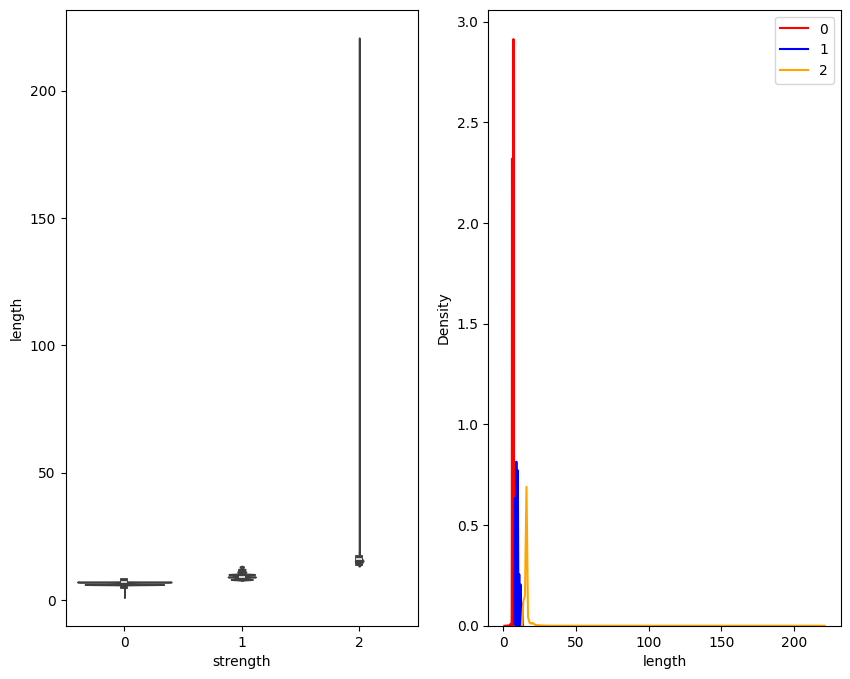

In [142]:
get_dist(data, "length")


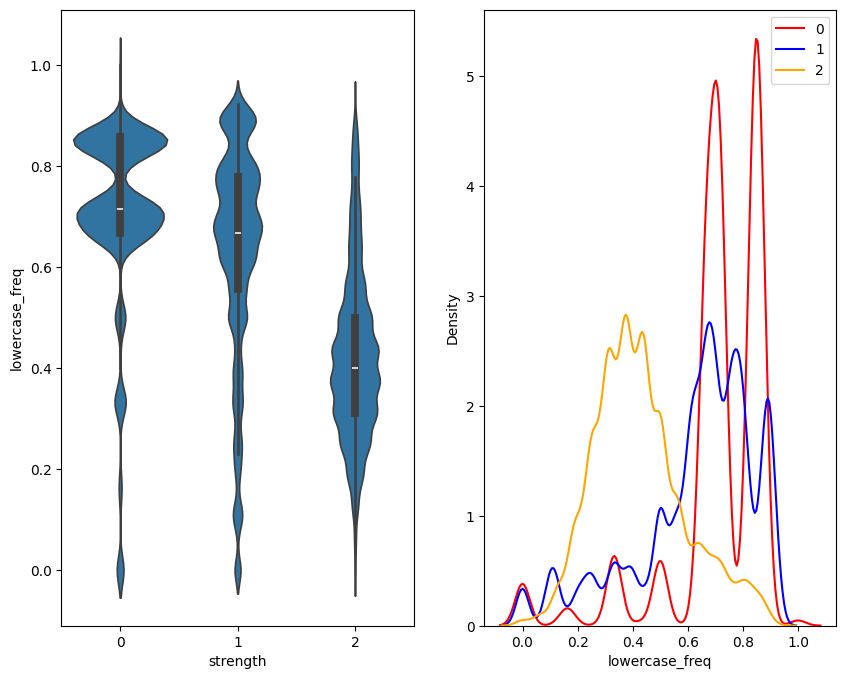

In [143]:
get_dist(data, "lowercase_freq")

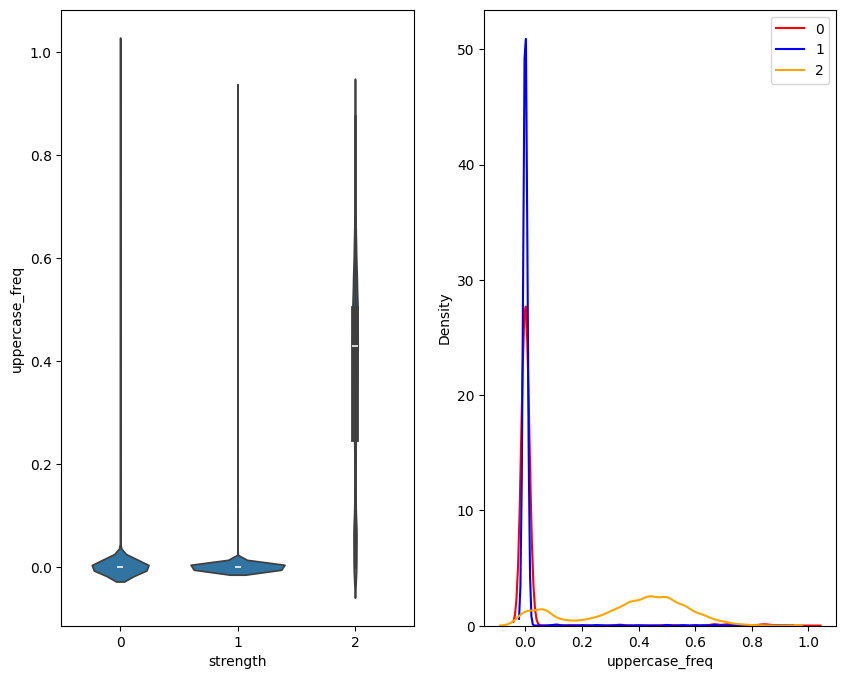

In [144]:
get_dist(data, "uppercase_freq")


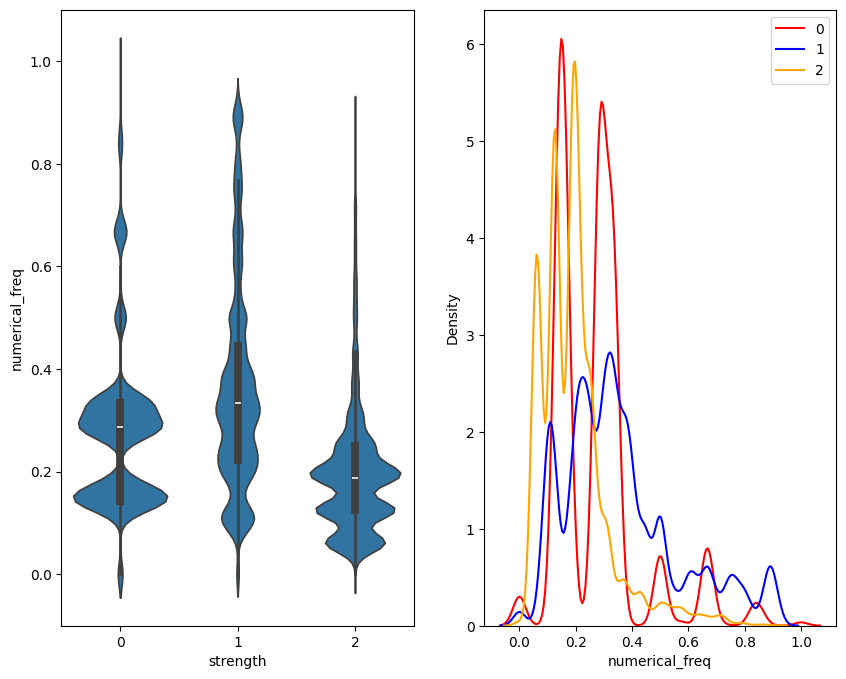

In [145]:
get_dist(data, "numerical_freq")


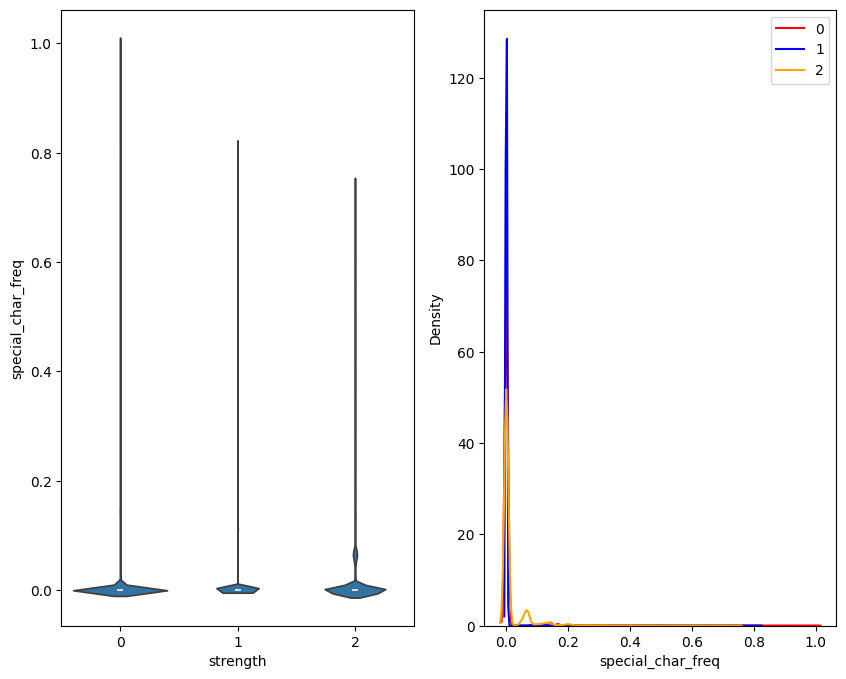

In [146]:
get_dist(data, "special_char_freq")


In [148]:
dataframe = data.sample(frac=1)

In [149]:
dataframe

,password,strength,length,lowercase_freq,uppercase_freq,numerical_freq,special_char_freq
78209,manon5,0,6,0.833,0.000,0.167,0.0
30592,souay9961,1,9,0.556,0.000,0.444,0.0
64137,caobito1984,1,11,0.636,0.000,0.364,0.0
684,WILLI17,0,7,0.000,0.714,0.286,0.0
39031,yfeodsjp083,1,11,0.727,0.000,0.273,0.0
...,...,...,...,...,...,...,...
41180,ihybu748,1,8,0.625,0.000,0.375,0.0
44874,ekinoxio12312,1,13,0.615,0.000,0.385,0.0
97746,6WtJmXTU0Mwy7eO7,2,16,0.312,0.438,0.250,0.0
53866,znzz5d2,0,7,0.714,0.000,0.286,0.0


In [154]:
x = list(dataframe["password"])

In [151]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [152]:
vectorizer = TfidfVectorizer(analyzer="char") 

In [155]:
X = vectorizer.fit_transform(x)

In [156]:
X.shape

(100000, 99)

In [157]:
dataframe["password"].shape

(100000,)

In [158]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 842571 stored elements and shape (100000, 99)>

In [159]:
X.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(100000, 99))

In [162]:
df2 = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

In [163]:
df2

,,,,,,,,,!,#,...,ñ,ó,õ,ö,÷,ú,ü,ý,þ,›
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [164]:
dataframe.columns

Index(['password', 'strength', 'length', 'lowercase_freq', 'uppercase_freq',
       'numerical_freq', 'special_char_freq'],
      dtype='str')

In [167]:
df2['length'] = dataframe['length']
df2['lowercase_freq'] = dataframe['lowercase_freq']

In [166]:
df2

,,,,,,,,,!,#,...,ó,õ,ö,÷,ú,ü,ý,þ,›,length
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
99996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
99997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9
99998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9


In [168]:
y = dataframe["strength"]

In [169]:
from sklearn.model_selection import train_test_split

In [170]:
X_train, X_test,y_train, y_test = train_test_split(df2, y, test_size=0.2, random_state = 42)

In [171]:
X_train.shape

(80000, 101)

In [172]:
y_train.shape

(80000,)

In [180]:
from sklearn.linear_model import LogisticRegression

In [184]:
clf = LogisticRegression(solver="lbfgs")

In [185]:
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [186]:
y_pred = clf.predict(X_test)

In [187]:
y_pred

array([1, 0, 1, ..., 1, 1, 0], shape=(20000,))

In [188]:
from collections import Counter

In [189]:
Counter(y_pred)

Counter({np.int64(1): 16928, np.int64(2): 1831, np.int64(0): 1241})

In [190]:
password = '%@123abcd'

In [191]:
sample_array = np.array([password])

In [192]:
sample_matrix = vectorizer.transform(sample_array)

In [193]:
sample_matrix.toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.71897928, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.14344586, 0.1659599 , 0.18587581, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.48741481, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.13814351, 0.23158091, 0.21637656,
        0.20807263, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

In [194]:
sample_matrix.toarray().shape

(1, 99)

In [195]:
len(password)

9

In [196]:
[char for char in password if char.islower()]

['a', 'b', 'c', 'd']

In [197]:
len([char for char in password if char.islower()])/len(password)

0.4444444444444444

In [199]:
np.append(sample_matrix.toarray(), (9, 0.444)).shape

(101,)

In [201]:
np.append(sample_matrix.toarray(), (9, 0.444)).reshape(1,101)

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.71897928, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.14344586, 0.1659599 , 0.18587581, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.48741481, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.13814351, 0.23158091, 0.21637656,
        0.20807263, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

In [202]:
np.append(sample_matrix.toarray(), (9, 0.444)).reshape(1,101).shape

(1, 101)

In [203]:
new_matrix = np.append(sample_matrix.toarray(), (9, 0.444)).reshape(1,101)

In [204]:
clf.predict(new_matrix)

array([0])

In [205]:
def predict():
    password = input("Enter a password : ")
    sample_array = np.array([password])
    sample_matrix = vectorizer.transform(sample_array)
    
    length_pass = len(password)
    length_normalised_lowercase = len([char for char in password if char.islower()])/len(password)
    
    new_matrix2 = np.append(sample_matrix.toarray() , (length_pass , length_normalised_lowercase)).reshape(1,101)
    result = clf.predict(new_matrix2)
    
    if result == 0 :
        return "Password is weak"
    elif result == 1 :
        return "Password is normal"
    else:
        return "password is strong"

In [207]:
predict()

'password is strong'

In [208]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [209]:
accuracy_score(y_test, y_pred)

0.79665

In [211]:
print(confusion_matrix(y_test, y_pred))

[[  643  2085     7]
 [  534 13849   383]
 [   64   994  1441]]
